In [1]:
from functools import partial
import pickle
from omegaconf import OmegaConf

import jax
import jax.numpy as jnp
import mediapy

key = jax.random.PRNGKey(0)

In [2]:
from omni_epic.envs.open_door import Env
from ppo.wrappers import (
	EpisodeWrapper,
	AutoResetWrapper,
	LogWrapper,
	ClipAction,
	VecEnv,
	NormalizeVecObservation,
	NormalizeVecReward,
)

env = Env()
# env = EpisodeWrapper(env, episode_length=1000, action_repeat=1)
# env = AutoResetWrapper(env)
# env = LogWrapper(env)
# env = ClipAction(env)
# env = VecEnv(env)
# env = NormalizeVecObservation(env)
# env = NormalizeVecReward(env, 0.99)

In [3]:
reset_fn = jax.jit(env.reset)
step_fn = jax.jit(env.step)

num_envs = 16

In [5]:
key, subkey = jax.random.split(key)
env_state = reset_fn(subkey)
images = [env.renderer(env_state)]
env_states = [env_state]
for _ in range(200):
	action = jnp.zeros(4)
	action = action.at[1].set(0.7)
	key, subkey = jax.random.split(key)
	env_state = step_fn(subkey, env_state, action)
	images.append(env.renderer(env_state))
	env_states.append(env_state)
	# manifolds = env.transform_manifolds(env_state.sim_state)
	# print(env.collision_cp(manifolds, env.robot_idx, env.button_idx,))
	print(env_state.reward)

-7.652387
-7.64018
-7.6224265
-7.599126
-7.57028
-7.53589
-7.495958
-7.450484
-7.399471
-7.34292
-7.2808332
-7.213214
-7.1400642
-7.0613866
-6.9771852
-6.8874636
-6.7922263
-6.691478
-6.5852237
-6.47347
-6.356225
-6.233496
-6.105292
-5.9716244
-5.832506
-5.6879516
-5.5379777
-5.382605
-5.2218585
-5.055767
-4.884364
-4.707694
-4.525809
-4.3387737
-4.14667
-3.949603
-3.7477093
-3.541167
-3.3302155
-3.1151857
-2.8965425
-2.6749594
-2.4514456
-2.2275765
-2.0059154
-1.790839
-1.8230187
-10.90066
-10.92662
-10.954266
-10.984206
-11.015375
-11.047517
-11.08043
-11.114038
-11.148282
-11.183108
-11.218456
-11.254026
-11.289611
-11.325096
-11.360368
-11.395281
-11.429682
-11.463417
-11.496335
-11.528351
-11.559338
-11.589121
-11.61752
-11.64434
-11.669378
-11.692428
-11.713419
-11.732288
-11.748983
-11.76346
-11.775687
-11.785637
-11.793295
-11.798657
-11.801728
-11.802522
-11.8010645
-11.797391
-11.791546
-11.78359
-11.773589
-11.761625
-11.747789
-11.732186
-11.714933
-11.696159
-11.676007
-11

""

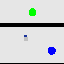

: 

In [6]:
mediapy.show_video(images, width=256, height=256, codec="gif")

""

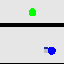

In [7]:
mediapy.show_image(images[45], width=256, height=256)

In [13]:
(env.physics_engine.circle_poly_pairs[:, 0] == env.button_idx).sum()

Array(0, dtype=int32)

In [11]:
env_states[45].sim_state.acc_cr_manifolds[env.button_idx, ]

CollisionManifold(normal=Array([[0., 0.],
       [0., 0.],
       [0., 0.],
       ...,
       [0., 0.],
       [0., 0.],
       [0., 0.]], dtype=float32), penetration=Array([0., 0., 0., ..., 0., 0., 0.], dtype=float32), collision_point=Array([[0., 0.],
       [0., 0.],
       [0., 0.],
       ...,
       [0., 0.],
       [0., 0.],
       [0., 0.]], dtype=float32), active=Array([False, False, False, ..., False, False, False], dtype=bool), acc_impulse_normal=Array([0., 0., 0., ..., 0., 0., 0.], dtype=float32), acc_impulse_tangent=Array([0., 0., 0., ..., 0., 0., 0.], dtype=float32), restitution_velocity_target=Array([0., 0., 0., ..., 0., 0., 0.], dtype=float32))

In [4]:
key, subkey = jax.random.split(key)
keys = jax.random.split(subkey, num_envs)
env_state = reset_fn(keys)
env_states = [env_state]
for _ in range(200):
	action = jnp.zeros((num_envs, 4))
	# action = action.at[0].set(0.2)
	key, subkey = jax.random.split(key)
	keys = jax.random.split(subkey, num_envs)
	env_state = step_fn(keys, env_state, action)
	env_states.append(env_state)

# # Move robot
# env_state = env.set_polygon_position(env_state, env.robot_idx, jnp.array([10.0, 10.0]))

# for _ in range(10):
# 	action = jnp.zeros(4)
# 	key, subkey = jax.random.split(key)
# 	env_state = step_fn(subkey, env_state, action)
# 	images.append(env.renderer(env_state))
# 	print(_, env_state.terminated)

# for _ in range(200):
# 	action = jnp.zeros(4)
# 	# action = -action.at[3].set(0.2)
# 	key, subkey = jax.random.split(key)
# 	env_state = step_fn(subkey, env_state, action)
# 	images.append(env.renderer(env_state))
# 	print(_, env_state.terminated)

In [5]:
mediapy.show_video([env_state.observation["image"][3] for env_state in env_states])

In [6]:
mediapy.show_video([env_state.observation["image"][3] for env_state in env_states])

In [7]:
mediapy.show_video([env_state.observation["image"][3] for env_state in env_states])

: 

""

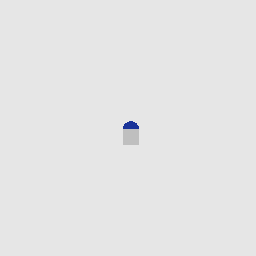

In [28]:
mediapy.show_image(env_states[0].observation["image"][1])

## Evaluate PPO

In [4]:
from ppo.ppo import ActorCritic
from ppo.wrappers import Jax2DWrapper

run_path = "/workdir/output/ppo/2024-11-22_200124_091094"
config = OmegaConf.load(f"{run_path}/.hydra/config.yaml")

env = Jax2DWrapper(config.env_path)

params = pickle.load(open(f"{run_path}/params.pickle", "rb"))
network = ActorCritic(env.action_space.shape[0])

In [8]:
reset_fn = jax.jit(env.reset)
step_fn = jax.jit(env.step)

key, subkey = jax.random.split(key)
env_state = reset_fn(subkey)
env_states = [env_state]
R = 0
for i in range(config.episode_length):
	# Act
	key, subkey = jax.random.split(key)
	pi, value = network.apply(params, env_state.observation)
	action = pi.sample(seed=subkey)

	# Step
	key, subkey = jax.random.split(key)
	env_state = step_fn(subkey, env_state, action)

	R += env_state.reward
	env_states.append(env_state)

	if env_state.terminated:
		break

In [9]:
mediapy.show_video([env.renderer(env_state) for env_state in env_states], width=256, height=256)

This browser does not support the video tag.


## Check collisions

In [ ]:
state = env.reset(None)
action = jnp.zeros(env.static_sim_params.num_joints + env.static_sim_params.num_thrusters)
current_state, manifolds = env.step_fn(state, env.sim_params, action)
env.collision_pp(manifolds, env.robot_idx, env.obstacle_idx)